# CrunchTope + rhea worked example — sweeping a selectivity coefficient

An end-to-end Omphalos experiment in which the swept parameter is not in the input deck. It is in
the thermodynamic database.

**The problem.** The CrunchFlow short-course exercise fits caesium sorption on Hanford sediments
with a three-site ion-exchange model. Those selectivity coefficients live in the `.dbs` and in no
keyword block — they are what PEST is pointed at in this community, and the reason
`database_parameters` exists.

**What it demonstrates.** A *surgical* edit. Each run gets its own copy of a 3,700-line database
differing from the template on exactly one line, with the column alignment intact. Nothing is
regenerated, and no other coefficient moves.

## 1. The experiment as written down

The config is the whole experimental design. Everything else in this notebook is downstream of it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

style = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style.exists():
    plt.style.use(str(style))

HERE = Path.cwd()
CONFIG = HERE / 'cesium_exchange.yaml'
DATABASE = 'HanfordTanksColumnFit3Site-GT.dbs'
RESULTS = HERE / 'results.nc'
CONDITIONS = HERE / 'conditions.nc'

print(CONFIG.read_text())

# Omphalos / CrunchTope example — sweeping a selectivity coefficient in the
# thermodynamic database.
#
# The CrunchFlow short-course exercise fits caesium sorption on Hanford sediments
# with a three-site ion-exchange model. Those selectivity coefficients live in the
# .dbs and in no keyword block, which is what PEST is pointed at in this community
# and what 'database_parameters' exists to reach.
#
# NaXhan1 is the Na-site-1 coefficient. The database writes log K for the
# *breakdown* of NaXhan1, so a larger value means Na holds site 1 less strongly
# and Cs competes better for it.
#
# Run with rhea (from this directory, omphalos environment active):
#     rhea cesium_exchange.yaml local --compile-inputs

### Frontmatter — mandatory keys. Leave blank if not applicable.
# Paths may be relative to this directory or absolute.
template: 'ShortCourse12a.in'
database: 'HanfordTanksColumnFit3Site-GT.dbs'
aqueous_database:
catabolic_pathways:
restart_file:

# Max wall-clock seconds per input

## 2. Run the sweep — in the shell, before opening this notebook

From this directory, with the `omphalos` environment active and CrunchTope installed:

```bash
rhea cesium_exchange.yaml local --compile-inputs      # about three minutes for three runs
```

`ShortCourse12a.in` names the other two decks as `later_inputfiles`, so each run is a chain of
three; Omphalos stages one database for all three.

`--compile-inputs` is what writes `conditions.nc`, which records the coefficient each run was given
— read back out of the database it ran against rather than re-derived from the YAML. That is what
makes a `random_uniform` sweep of a database parameter recoverable afterwards.

In [2]:
missing = [f.name for f in (RESULTS, CONDITIONS) if not f.exists()]
if missing:
    raise FileNotFoundError(f'{", ".join(missing)} not found — run the command above first.')

sorbed = xr.open_dataset(RESULTS, group='totexchange')
aqueous = xr.open_dataset(RESULTS, group='totcon')
sorbed

<xarray.Dataset> Size: 54kB
Dimensions:   (file_num: 3, time: 2, X: 100, Y: 1, Z: 1)
Coordinates:
  * X         (X) float64 800B 0.0007614 0.002284 0.003807 ... 0.15 0.1515
  * Y         (Y) float64 8B 0.5
  * Z         (Z) float64 8B 0.5
  * time      (time) float64 16B 19.25 144.2
  * file_num  (file_num) int64 24B 0 1 2
Data variables:
    Cs+       (file_num, time, X, Y, Z) float64 5kB ...
    Na+       (file_num, time, X, Y, Z) float64 5kB ...
    Ca++      (file_num, time, X, Y, Z) float64 5kB ...
    Mg++      (file_num, time, X, Y, Z) float64 5kB ...
    I-        (file_num, time, X, Y, Z) float64 5kB ...
    Tracer    (file_num, time, X, Y, Z) float64 5kB ...
    H+        (file_num, time, X, Y, Z) float64 5kB ...
    HCO3-     (file_num, time, X, Y, Z) float64 5kB ...
    K+        (file_num, time, X, Y, Z) float64 5kB ...
    NO3-      (file_num, time, X, Y, Z) float64 5kB ...
    Cl-       (file_num, time, X, Y, Z) float64 5kB ...

## 3. What each run actually used

In [3]:
swept = xr.open_dataset(CONDITIONS, group='database_parameters/exchange/NaXhan1')
log_k = [float(value) for value in swept['log_k'].values]
log_k

[6.25224, 7.25224, 8.25224]

## 4. The databases really do differ, and only where they should

In [4]:
import io


def lines_of(path):
    with io.open(path, newline='') as file:      # the databases are CRLF; keep them that way
        return file.readlines()


template = lines_of(HERE / DATABASE)

for run in range(len(log_k)):
    row = next(line for line in lines_of(HERE / f'run{run}' / DATABASE)
               if line.startswith("'NaXhan1'"))
    print(f'run{run}: {row.strip()}')

print()
for run in range(len(log_k)):
    run_lines = lines_of(HERE / f'run{run}' / DATABASE)
    differing = [i for i, (a, b) in enumerate(zip(template, run_lines)) if a != b]
    print(f'run{run}: {len(differing)} line(s) differ from the template — {differing}')

run0: 'NaXhan1' 2  1.0 'Na+' 1.0 'Xhan1-'               6.25224  0.000
run1: 'NaXhan1' 2  1.0 'Na+' 1.0 'Xhan1-'               7.25224  0.000
run2: 'NaXhan1' 2  1.0 'Na+' 1.0 'Xhan1-'               8.25224  0.000

run0: 1 line(s) differ from the template — [3662]
run1: 0 line(s) differ from the template — []
run2: 1 line(s) differ from the template — [3662]


At most one changed line out of 3,691, with the column alignment intact — and run 1 changes none,
because 7.25224 is the fitted value this sweep brackets, so its database is byte-identical to the
template. Everything else in the file — stoichiometry, the other fourteen exchange coefficients, the
mineral kinetics block — is byte for byte as it was.

## 5. The effect

The database writes log K for the *breakdown* of `NaXhan1`, so a **larger** value means sodium holds
site 1 less strongly and caesium competes better for it. Sorbed Cs should rise with the coefficient,
and aqueous Cs fall.

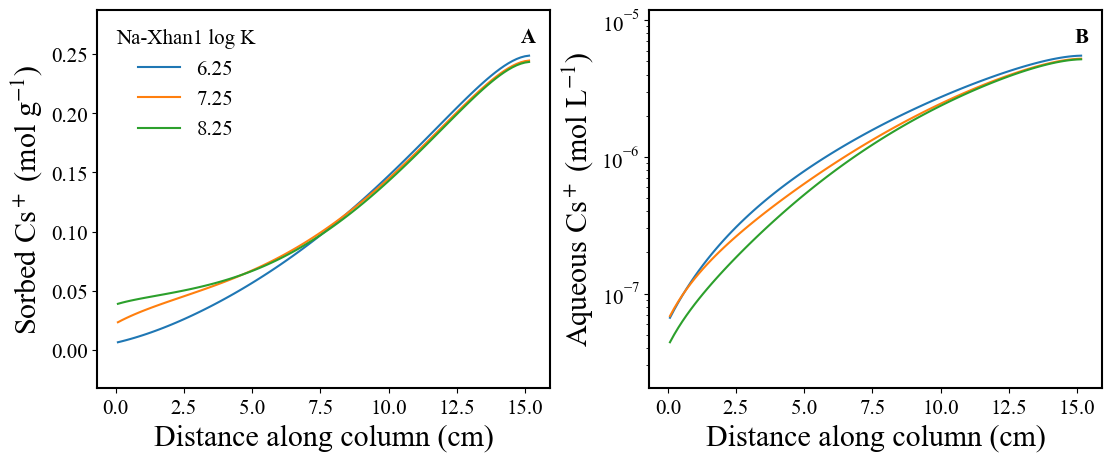

In [5]:
distance = sorbed.X.values * 100  # m -> cm

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for run, coefficient in enumerate(log_k):
    label = f'{coefficient:.2f}'
    axes[0].plot(distance, sorbed['Cs+'].isel(file_num=run, time=-1, Y=0, Z=0), label=label)
    axes[1].plot(distance, aqueous['Cs+'].isel(file_num=run, time=-1, Y=0, Z=0), label=label)

axes[0].set_ylabel('Sorbed Cs$^+$ (mol g$^{-1}$)')
axes[1].set_ylabel('Aqueous Cs$^+$ (mol L$^{-1}$)')
axes[1].set_yscale('log')

for axis, letter in zip(axes, 'AB'):
    # Headroom, so the panel letter clears the curve tips it used to sit on.
    axis.margins(y=0.16)
    axis.set_xlabel('Distance along column (cm)')
    axis.text(0.97, 0.95, letter, transform=axis.transAxes,
              fontweight='bold', va='top', ha='right')

axes[0].legend(title='Na-Xhan1 log K', frameon=False, loc='upper left')

figure.savefig(HERE / 'cesium_exchange.png', dpi=200)

The curves separate at the column inlet, where the exchanger is still competing for caesium,
and converge downstream where the sites are saturated regardless. Sorbed caesium rises with the
coefficient and aqueous caesium falls, which is the direction the breakdown convention implies.

Column-mean values at the last snapshot:

In [6]:
for run, coefficient in enumerate(log_k):
    s = float(sorbed['Cs+'].isel(file_num=run, time=-1).mean())
    a = float(aqueous['Cs+'].isel(file_num=run, time=-1).mean())
    print(f'log K {coefficient:7.5f}   sorbed {s:.6e}   aqueous {a:.6e}')

log K 6.25224   sorbed 1.117995e-01   aqueous 2.116012e-06
log K 7.25224   sorbed 1.172134e-01   aqueous 1.923826e-06
log K 8.25224   sorbed 1.179953e-01   aqueous 1.843835e-06


## 6. Notes

- The three decks are copies of the exercise's, changed in one respect only: `graphics tecplot`
  instead of `kaleidagraph`, so Omphalos can collate the output. The change is written into each
  deck as a comment, and the chemistry is untouched.
- The same sweep run sequentially with `omphalos` reproduces these numbers to every digit, as does a
  two-stage `restart_chain`.